# Inter-annual

In [1]:
import os.path
from secrets import randbelow
from statistics import median

import pandas as pd
import numpy as np
from numpy.ma.core import shape

COMPOSITES_NO_NAN_DIR = "/run/media/martin/KINGSTON/NDVI/test_area_no_nan"
COMPOSITES_NO_NAN_LOG_PATH = os.path.join(COMPOSITES_NO_NAN_DIR, "log.csv")

# physical = digital * scale_factor + add_offset
# 0.1 = 0.004*digital - 0.08
# (0.1 + 0.08)/0.004 =  = digital = 45
THRESHOLD = 45 # 0.1 physical 

In [2]:
inventory = pd.read_csv(COMPOSITES_NO_NAN_LOG_PATH, index_col=0, header = 0)

min_year = inventory.year.min()
max_year = inventory.year.max()

min_month = inventory.month.min()
max_month = inventory.month.max() 

inventory = inventory.set_index(["year", "month"])


#### Vizualization

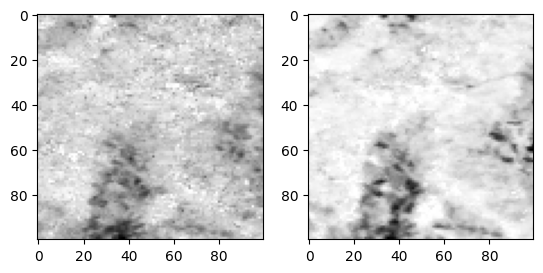

In [3]:
from matplotlib import pyplot as plt

path_start = inventory.loc[(2018, 6)]["path"]
sample_start = np.load(path_start)

path_end = inventory.loc[(2023,6)]["path"]
sample_end = np.load(path_end)

fig, (ax1, ax2) = plt.subplots(1, 2)

ax1.imshow(sample_start, cmap=plt.get_cmap("gray"))
ax2.imshow(sample_end, cmap=plt.get_cmap("gray"))

plt.show()


####  backward differences


In [3]:
# Loads observation into matrix [year, month]
composite_matrix = [] # [year, month]

for year in range(min_year,max_year+1):
    composite_matrix.append([])
    for month in range(min_month,max_month+1):
        new_composit = np.load(inventory.loc[(year,month)]["path"])
        composite_matrix[-1].append(new_composit)


In [4]:
composite_matrix = np.array(composite_matrix)
print(composite_matrix.shape)

(6, 5, 100, 100)


for generic month $ m' $ and subset of composites $ \textbf{X}_m' =  \left\{ X_{y, m = m'} \right\}; y \in \left\{ min\_year, ..., max\_year \right\} $ 

$ X^{BD}_{y,m'} = X_{y,m'}-X_{y-1, m'} $

In [5]:
X_BD = np.empty(composite_matrix.shape) #Back diference
X_BD[:] = np.nan


for i in range(1, composite_matrix.shape[0]):
    X_BD[i,:] = composite_matrix[i,:] - composite_matrix[i-1,:]
    

In [7]:
# check of BD computation
for m in range(0, composite_matrix.shape[1]):
    for yr in  range(1, composite_matrix.shape[0]):
        for x in range(1, composite_matrix.shape[2]):
            for y in range(1, composite_matrix.shape[3]):
                expected = composite_matrix[yr,m,x,y] - composite_matrix[yr-1,m,x,y]
                calculated = X_BD[yr,m,x,y]
                
                if expected != calculated:
                    raise Exception (f"Value {calculated} does not match expected {expected} at {yr},{m},{x},{y}")

#### Visualize

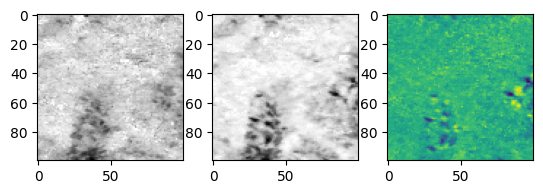

[[ 9. 15. 14. ... 23. 10. 14.]
 [11. 22. 16. ... 16. 23. 30.]
 [15. 17.  9. ...  7.  6. -9.]
 ...
 [15. 22. 18. ... 11. 17. 10.]
 [20. 23. 35. ...  8. 15.  5.]
 [30. 29. 29. ...  3.  9. 12.]]


In [23]:
fig, ax = plt.subplots(1,3)

ax[0].imshow(composite_matrix[0,0], cmap=plt.get_cmap("gray"))
ax[1].imshow(composite_matrix[1,0], cmap=plt.get_cmap("gray"))

ax[2].imshow(X_BD[1,0])


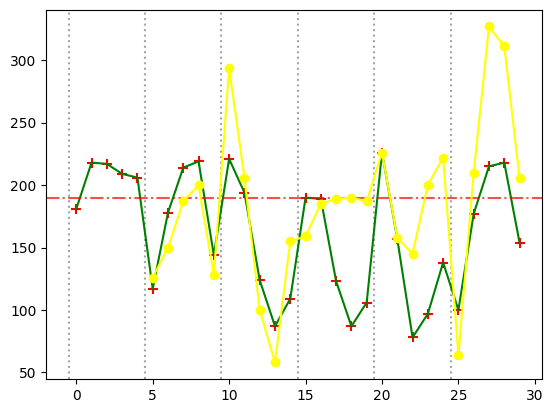

In [71]:
#OBSERVED_POINT = [21,40]
#OBSERVED_POINT = [40,80]
#OBSERVED_POINT = [40,99]
OBSERVED_POINT = [25,60]
OBSERVED_POINT = [0,33]
OBSERVED_POINT = [0,44]
FAKE_ZERO_LINE = 190

time_serie_one_point = []
time_serie_bd = []
counter = -0.5
for y in range(composite_matrix.shape[0]):
    plt.axvline(x=counter, color='gray', linestyle=':', alpha=0.7)
    for m in range(composite_matrix.shape[1]):
        time_serie_one_point.append(composite_matrix[y,m,OBSERVED_POINT[0],OBSERVED_POINT[1]])
        time_serie_bd.append(X_BD[y,m,OBSERVED_POINT[0],OBSERVED_POINT[1]]+FAKE_ZERO_LINE)
        counter += 1
        

plt.plot(time_serie_one_point, color='green')
plt.scatter(y=time_serie_one_point, x=range(len(time_serie_one_point)), color='red', marker='+', alpha=1, s=50)

plt.axhline(y = FAKE_ZERO_LINE, color='red', linestyle='-.', alpha=0.7)
plt.plot(time_serie_bd, color='yellow', marker='o')

plt.show()

[  nan  -64.  104.  -31.   36. -126.]


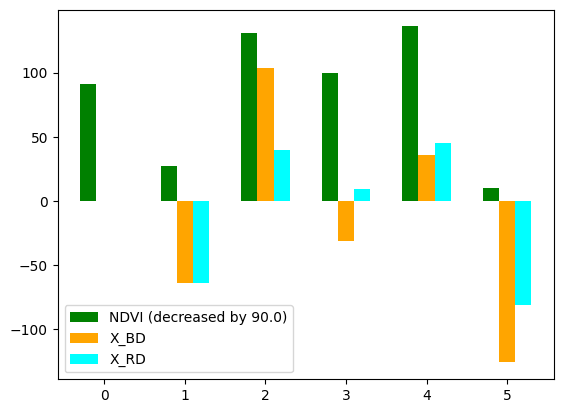

In [72]:
month = 0
width = 0.2

x_NDVI = [x - width for x in range(composite_matrix.shape[1]+1)]
x_X_BD = [x for x in range(composite_matrix.shape[1]+1)]
x=["2018", "2019", "2020", "2021", "2022", "2023"]


off_set = np.min(composite_matrix[:,month, OBSERVED_POINT[0], OBSERVED_POINT[1]])-10
plt.bar(x_NDVI, composite_matrix[:,month, OBSERVED_POINT[0], OBSERVED_POINT[1]]-off_set, width=width, color = 'green', label=f"NDVI (decreased by {off_set})")
plt.bar(x_X_BD, X_BD[:,month, OBSERVED_POINT[0], OBSERVED_POINT[1]], width=width, color = 'orange', label="X_BD")


y_f =  np.argmax(X_BD[:,month,OBSERVED_POINT[0],OBSERVED_POINT[1]] < 0)
print(X_BD[:,month,OBSERVED_POINT[0],OBSERVED_POINT[1]])
if (y_f > 0):
    v_X_RD = [ composite_matrix[y,month,OBSERVED_POINT[0],OBSERVED_POINT[1]] - composite_matrix[y_f-1,month,OBSERVED_POINT[0],OBSERVED_POINT[1]] for y in range(y_f, composite_matrix.shape[0])  ]
    
    x_X_RD = [x + width for x in range(y_f, composite_matrix.shape[1]+1)]
    plt.bar(x_X_RD, v_X_RD, width=width, color = 'cyan', label="X_RD")

plt.legend()

We then identify the first year that exhibits a negative variation in the spectral index, compared to the previous year, with an absolute value greater than a threshold $ y_f $

In [51]:
# We then identify the first year that exhibits a negative variation in the spectral index, compared to the previous year, with an absolute value greater than a threshold 
negative_mask = X_BD < 0
sus_mask = np.logical_and( np.absolute(X_BD) >= THRESHOLD, negative_mask )

print(np.sum(negative_mask), "of neg")
print(np.sum(sus_mask), "of sus")




105305 of neg
4452 of sus


Year $ y_f $ is the last one before the vegetation index drops and $ X_{y_f-1, m'} $ can be considered as a reference value in pre-disturbance conditions.

This value is used to compute $ X^{RD}_{y,m'} = X_{y,m'} - X_{y_f-1,m'} ; y \in \{ y_f,... \} $

We consider as disturbed areas only the pixels that show a negative variation of the index from the reference year for at least three years.

Given the first year of detection $ y_d $, the pixel is considered as disturbed if $ X^{RD}_{y,m'} \le TH \quad \forall\   y \in \{ y_d,...,y_d+3 \} $.

If the number of years available in the time series after the first detection is less than three, or zero in the case of near real-time detection, the condition is still considered fulfilled




In [52]:

def check_disturbance_condition(X_RD) -> bool:
    years_negative_trend_from_reference_year = np.logical_and( X_RD < 0, np.absolute(X_RD) >= THRESHOLD)
    
    countOfContinuousDisturbances = 0
    for x_rd in years_negative_trend_from_reference_year:
        if x_rd:
            countOfContinuousDisturbances += 1
        else:
            break
        
    return countOfContinuousDisturbances >= 4 or countOfContinuousDisturbances == len(X_RD)

In [53]:
M = []
for month in range(composite_matrix.shape[1]):
    sus_mask_month = sus_mask[:,month, :, :] # shape = [6, 100, 100] => 6-year , 100-pix_w, 100-pix_h
    #print(sus_mask_month.shape)
    
    m = np.zeros(sus_mask_month.shape[1:])
    for x in range(sus_mask_month.shape[-2]):
        for y in range(sus_mask_month.shape[-1]):
            sus_mask_month_point = sus_mask_month[:,x,y] # one point in month month over more years
            
            y_d = -1
            
            y_f_potentionals = np.where(sus_mask_month_point == True)
            if len(y_f_potentionals[0]) > 0:
                #print(y_f_potentionals)
                y_f = y_f_potentionals[0][0]
                X_y_f_m1 = composite_matrix[y_f-1, month, x, y] # reference value form prev year
                X_RD = np.array([ X_y - X_y_f_m1 for X_y in composite_matrix[y_f : ,month, x, y] ])
                
                condition_met = check_disturbance_condition(X_RD)
                if(check_disturbance_condition(X_RD)):
                    y_d = y_f
            
            m[x,y] = y_d
            
    M.append(m)     
        
M = np.array(M)    
print(shape(sus_mask_month))
print(np.sum( M > -1 ))
    

(6, 100, 100)
752


# Intra-annual

|  Level  |                           Rule                           |
|:-------:|:--------------------------------------------------------:|
|   Low   |                  Detected for one month                  |
| Medium  |         Detected for two months in the same year         |
|  High   | Detected for more than two months or two different years |

In [54]:
disturbance_years = np.zeros(composite_matrix.shape[-2:])

disturbance_reliability = np.zeros(disturbance_years.shape)
disturbance_reliability[:] = np.nan

from enum import Enum
class Detection_Reliability_Metric(Enum):
    Low = 1     # Detected for one month 
    Medium = 2  # Detected for two months in the same year
    High = 3    # Detected for more than two months or two different years
    Ambiguous = 0 # Cannot be clearly identified (f.e. it is last in time series)
    
def categorize_slic_through_months(slice) -> Detection_Reliability_Metric:
    month_of_detection = np.nanargmin(slice)
    
    if month_of_detection + 1 >= len(slice):
        return Detection_Reliability_Metric.Ambiguous
    
    months_after_detection = slice[month_of_detection : ] 
    
    found_in_months =  np.sum( np.logical_not(np.isnan(months_after_detection)) )
    found_in_years = len(np.unique(months_after_detection)) # nan is also unique value
    
    if (found_in_months > 2 or found_in_years > 3):
        return Detection_Reliability_Metric.High
    elif (found_in_months == 2 and found_in_years <= 2):
        return Detection_Reliability_Metric.Medium
    elif (found_in_months < 2):
        return Detection_Reliability_Metric.Low
    
    return Detection_Reliability_Metric.Ambiguous # Fallback
    

In [55]:
M[M==-1] = np.nan
disturbance_years = np.nanmin(M, axis=0) # ! step not in instruction !


for x in range(disturbance_years.shape[0]):
    for y in range(disturbance_years.shape[1]):
        if( np.isnan( disturbance_years[x,y] ) ): # if is nan continue
            continue

        point_throw_months = M[:,x,y]
        disturbance_reliability[x,y] = categorize_slic_through_months(point_throw_months).value   
        


/tmp/ipykernel_10737/1959146944.py:2: RuntimeWarning: All-NaN slice encountered
  disturbance_years = np.nanmin(M, axis=0) # ! step not in instruction !


## Save as .nc

In [58]:
# Reference metadata
import xarray as xr

PATH_TO_METADATA_SAMPLE = "/run/media/martin/KINGSTON/NDVI/test_area/EU_c_gls_NDVI300_201806010000_GLOBE_PROBAV_V3.0.1.nc"
sample = xr.open_dataset(PATH_TO_METADATA_SAMPLE)

print(sample.keys())

#time = sample['time']
lat = sample['lat']
lon = sample['lon']
crs = sample["crs"]

# print(time)
# print(lat, lon)
# print(disturbance_years.shape)
# print(disturbance_reliability.shape)
# print(lat.shape)
# print(lon.shape)

sample.close()

disturbance_years_mapped = np.array(disturbance_years)
disturbance_years_mapped[ np.logical_not(np.isnan(disturbance_years)) ] += min_year

disturbance_year_da = xr.DataArray(
    disturbance_years_mapped,
    dims=("lat", "lon"),
    coords={
        "lat": lat,
        "lon": lon
    },
    name="disturbance_year_detected"
)

disturbance_reliability_da = xr.DataArray(
    disturbance_reliability,
    dims=("lat", "lon"),
    coords={
        "lat": lat,
        "lon": lon
    },
    name="disturbance_reliability"
)

disturbance_layer = xr.Dataset(
    {
        "disturbance_year_detected": disturbance_year_da,
        "disturbance_reliability": disturbance_reliability_da
    }
)

print("--------------------------------")
print(disturbance_layer.keys())

disturbance_layer.to_netcdf("/run/media/martin/KINGSTON/NDVI/disturbance.nc")

KeysView(<xarray.Dataset> Size: 242kB
Dimensions:   (time: 1, lat: 100, lon: 100)
Coordinates:
  * time      (time) datetime64[ns] 8B 2018-06-01
  * lat       (lat) float64 800B 49.06 49.06 49.05 49.05 ... 48.77 48.77 48.76
  * lon       (lon) float64 800B 18.51 18.51 18.52 18.52 ... 18.8 18.8 18.81
Data variables:
    crs       |S1 1B ...
    NDVI      (time, lat, lon) float64 80kB ...
    NDVI_unc  (time, lat, lon) float64 80kB ...
    NOBS      (time, lat, lon) float32 40kB ...
    QFLAG     (time, lat, lon) float32 40kB ...
Attributes: (12/19)
    Conventions:          CF-1.6
    processing_level:     L3
    identifier:           urn:cgls:global:ndvi300_v3_333m:NDVI300_20180601000...
    institution:          VITO NV
    time_coverage_end:    2018-06-10T23:59:59Z
    source:               Derived from EO satellite imagery
    ...                   ...
    time_coverage_start:  2018-06-01T00:00:00Z
    platform:             PROBAV
    title:                10-daily Normalized Differ